### makemore: part 3

In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [4]:
words = open('names.txt', 'r').read().splitlines()
print(words[:8], len(words))

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia'] 32033


In [5]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi  = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos  = {i: s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos, stoi,vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'} {'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0} 27


In [6]:
block_size = 3

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr,  Ytr  = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte,  Yte  = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [16]:
n_embd = 10
n_hidd = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),           generator = g)
W1 = torch.randn((block_size * n_embd, n_hidd), generator = g) * ((5 / 3) / ((block_size * n_embd) ** 0.5))# 0.2
# b1 = torch.randn(n_hidd,                        generator = g) * 0.01
W2 = torch.randn((n_hidd, vocab_size),          generator = g) * 0.01
b2 = torch.randn(vocab_size,                    generator = g) * 0

bngain         = torch.ones((1, n_hidd))
bnbias         = torch.zeros((1, n_hidd))
bnstd_running  = torch.ones((1, n_hidd))
bnmean_running = torch.zeros((1, n_hidd))

parameters = [C, W1, W2, b2, bnbias, bngain]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

12097


In [17]:
max_steps   = 200000
batch_size  = 32
lossi       = []

for i in range(200000):
    # minibatch construct
    ix      = torch.randint(0, Xtr.shape[0], (batch_size, ))
    Xb, Yb  = Xtr[ix], Ytr[ix]

    # forward pass
    emb     = C[Xb]
    embcat  = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 # + b1

    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi  = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi - bnbias

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running  = 0.999 * bnstd_running  + 0.001 * bnstdi

    h       = torch.tanh(hpreact)
    logits  = h @ W2 + b2
    loss    = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update

    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f"{i: 7d}/{max_steps: 7d}, loss: {loss.item():.4f}")
    lossi.append(loss.log10().item())
    # break

print("loss:", loss.item())

      0/ 200000, loss: 3.3118
  10000/ 200000, loss: 2.5578
  20000/ 200000, loss: 2.0611
  30000/ 200000, loss: 1.9418
  40000/ 200000, loss: 2.0026
  50000/ 200000, loss: 2.0347
  60000/ 200000, loss: 1.9782
  70000/ 200000, loss: 1.9866
  80000/ 200000, loss: 2.4243
  90000/ 200000, loss: 1.9967
 100000/ 200000, loss: 2.5947
 110000/ 200000, loss: 2.3976
 120000/ 200000, loss: 2.0940
 130000/ 200000, loss: 2.3792
 140000/ 200000, loss: 2.2262
 150000/ 200000, loss: 2.2322
 160000/ 200000, loss: 2.4768
 170000/ 200000, loss: 2.2653
 180000/ 200000, loss: 2.0327
 190000/ 200000, loss: 2.2961
loss: 2.380645990371704


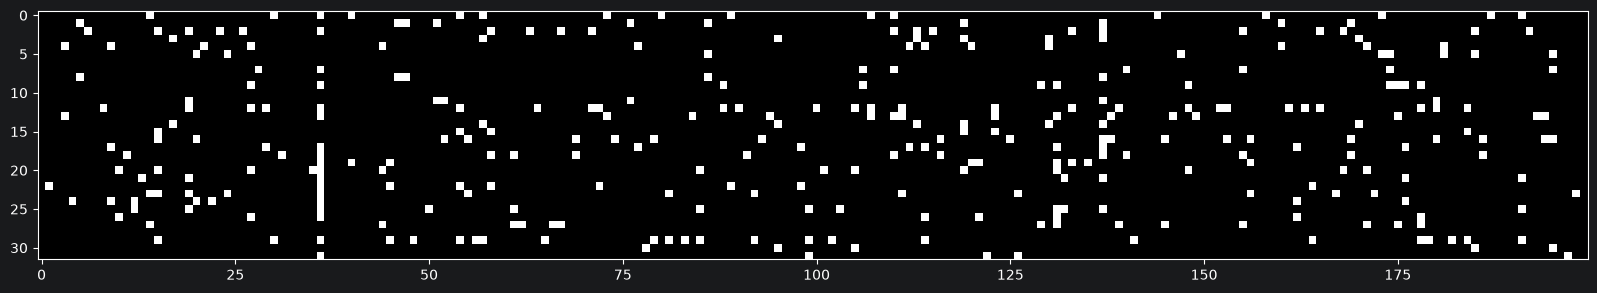

In [18]:
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap = 'gray', interpolation = 'nearest')

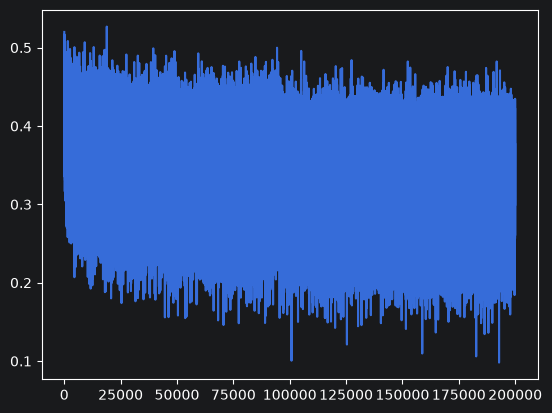

In [19]:
plt.plot(lossi)

In [20]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'valid': (Xdev,Ydev),
        'test ': (Xte, Yte),
    }[split]

    emb     = C[x]
    embcat  = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running - bnbias
    h       = torch.tanh(hpreact)
    logits  = h @ W2 + b2
    loss    = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('valid')
split_loss('test ')

train 2.066648006439209
valid 2.10807728767395
test  2.1050992012023926


In [21]:
g2 = torch.Generator().manual_seed(2147483647 + 10)
for _ in range(40):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        embcat = emb.view(1, -1)
        hpreact = embcat @ W1
        # hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) - bnbias
        h   = torch.tanh(hpreact)
        logits = h @ W2 + b2
        probs  = F.softmax(logits, dim = 1)
        ix     = torch.multinomial(probs, num_samples = 1, replacement = True, generator = g2).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

chrishfadibhlvightmrexxthvykhnlassac.
katubnfaverric.
kaqsic.
katalshckziiviktne.
kydh.
maddishedgruzssoulbitvithi.
wstell.
diaruxizfk.
diviuslyvedhedliz.
kyasshyaf.
kharquispac.
ksyahnnqqovozswy.
kjamiriasratnykelsadluugdno.
betkgiangrondra.
prlyttraydedensloquell.
brianapkerzlatgb.
fmszidghr.
sislattk.
chmyahnnyjahlahkingsabubezamduetz.
kyam.
claiorgurgwyn.
kayrk.
brck.
zallyzss.
khleiargusturrschpryssyfbarykelsabclissaidhyahnn.
khasdryassabhk.
kyaidhux.
khsxisnnv.
khal.
bitza.
righkobannyiahlidghnn.
jozquswvithviaspsdabrukweidhvishantyshbnlushmylenakeyth.
kalekytz.
khyldysil.
khma.
sachmjusummberghnnyka.
zakiirsbe.
santwentavlorineghtlrionielr.
kedgajmakiyab.
katzightz.


that's not a respectable result...
---

but let's train a deeper one.

In [7]:
# Let's train a deeper network.
class Linear:
    def __init__(self, fan_in, fan_out, bias = True):
        g           = torch.Generator().manual_seed(2147483647)
        # Kaiming initialization
        self.weight = torch.randn((fan_in, fan_out), generator = g) / fan_in ** 0.5
        self.bias   = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:
    """affine will be true which means using gamma and beta during training.
    track_running_stats will be true, keep tracking running mean and variance.
    device by default is cpu(but i hope is gpu.).
    datatype float32.
    """
    def __init__(self, dim, eps = 1e-5, momentum = 0.1):
        self.eps      = eps
        self.momentum = momentum
        self.training = True

        # parameters (trained with backprop.)
        self.gamma = torch.ones(dim)
        self.beta  = torch.zeros(dim)

        # buffers (trained with a running momentum update)
        self.running_mean = torch.zeros(dim)
        self.running_var  = torch.ones(dim)

    def __call__(self, x):
        # calculate the forward pass.
        if self.training:
            xmean = x.mean(0, keepdim = True) # batch mean
            xvar  = x.var(0, keepdim = True)  # batch variance
        else:
            xmean = self.running_mean
            xvar  = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalized to unit variance
        self.out = self.gamma * xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var  = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

In [8]:
n_embd = 10
n_hidd = 100
g      = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator = g)
layers = [
    Linear(n_embd * block_size, n_hidd), BatchNorm1d(n_hidd), Tanh(),
    Linear(             n_hidd, n_hidd), BatchNorm1d(n_hidd), Tanh(),
    Linear(             n_hidd, n_hidd), BatchNorm1d(n_hidd), Tanh(),
    Linear(             n_hidd, n_hidd), BatchNorm1d(n_hidd), Tanh(),
    Linear(             n_hidd, n_hidd), BatchNorm1d(n_hidd), Tanh(),
    Linear(             n_hidd, vocab_size), BatchNorm1d(vocab_size),
]

with torch.no_grad():
    # last layer, make less output softmax confident
    layers[-1].gamma *= 0.1
    # layers[-1].weight *= 0.1
    # all other layers apply gain.
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5 / 3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print("param_num: ", sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

param_num:  47551


In [9]:
max_steps   = 200000
batch_size  = 32
lossi       = []
ud          = []

for i in range(200000):

    # minibatch construct
    ix      = torch.randint(0, Xtr.shape[0], (batch_size, ))
    Xb, Yb  = Xtr[ix], Ytr[ix] # Batch X and Y.

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    x   = emb.view(emb.shape[0], -1) # concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    # backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    # update

    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f"{i: 7d}/{max_steps: 7d}, loss: {loss.item():.4f}")
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

print("loss:", loss.item())

      0/ 200000, loss: 3.3126
  10000/ 200000, loss: 2.3673
  20000/ 200000, loss: 2.1985
  30000/ 200000, loss: 1.8112
  40000/ 200000, loss: 2.0730
  50000/ 200000, loss: 2.1048
  60000/ 200000, loss: 1.8716
  70000/ 200000, loss: 2.0208
  80000/ 200000, loss: 1.9783
  90000/ 200000, loss: 2.3120
 100000/ 200000, loss: 2.2930
 110000/ 200000, loss: 2.4493
 120000/ 200000, loss: 1.9986
 130000/ 200000, loss: 1.9110
 140000/ 200000, loss: 2.2747
 150000/ 200000, loss: 2.0632
 160000/ 200000, loss: 2.0980
 170000/ 200000, loss: 2.1063
 180000/ 200000, loss: 2.4047
 190000/ 200000, loss: 1.8841
loss: 1.8256866931915283


layer 2 (      Tanh): mean +0.02, std 0.69, saturated 14.31%
layer 5 (      Tanh): mean -0.01, std 0.72, saturated 16.34%
layer 8 (      Tanh): mean +0.01, std 0.76, saturated 16.97%
layer 11 (      Tanh): mean -0.02, std 0.77, saturated 15.72%
layer 14 (      Tanh): mean -0.03, std 0.78, saturated 19.72%


Text(0.5, 1.0, 'activation distribution')

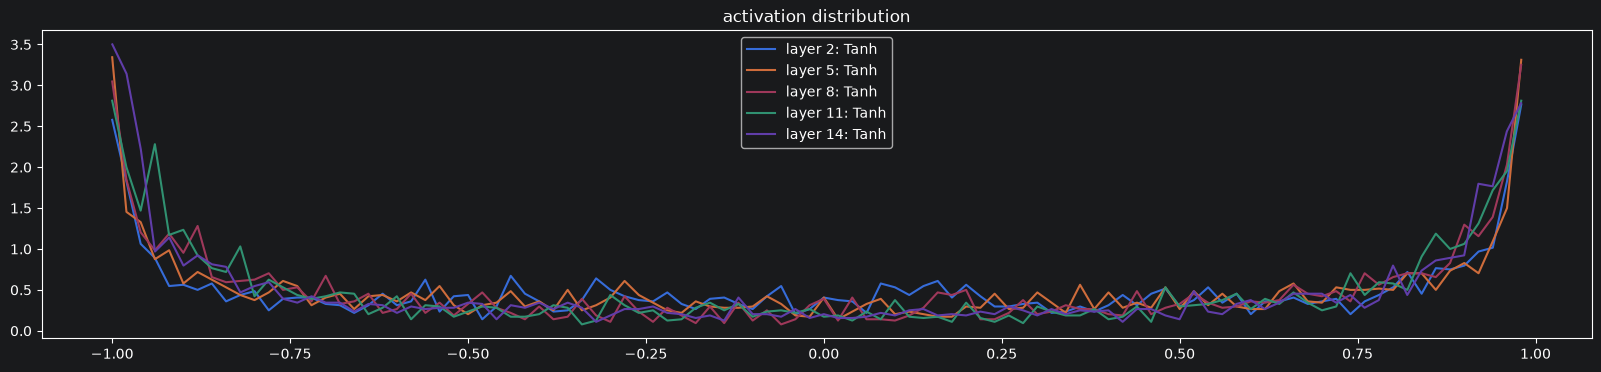

In [10]:
# visualize histograms
plt.figure(figsize = (20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated %.2f%%' % (i, layer.__class__.__name__, t.mean().item(), t.std().item(), (t.abs() > 0.97).float().mean().item() * 100))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i}: {layer.__class__.__name__}')
plt.legend(legends)
plt.title('activation distribution')

layer 2 (      Tanh): mean +0.000000, std 4.258321e-03
layer 5 (      Tanh): mean -0.000000, std 3.919737e-03
layer 8 (      Tanh): mean +0.000000, std 3.916336e-03
layer 11 (      Tanh): mean -0.000000, std 3.659446e-03
layer 14 (      Tanh): mean -0.000000, std 3.767202e-03


Text(0.5, 1.0, 'gradient distribution')

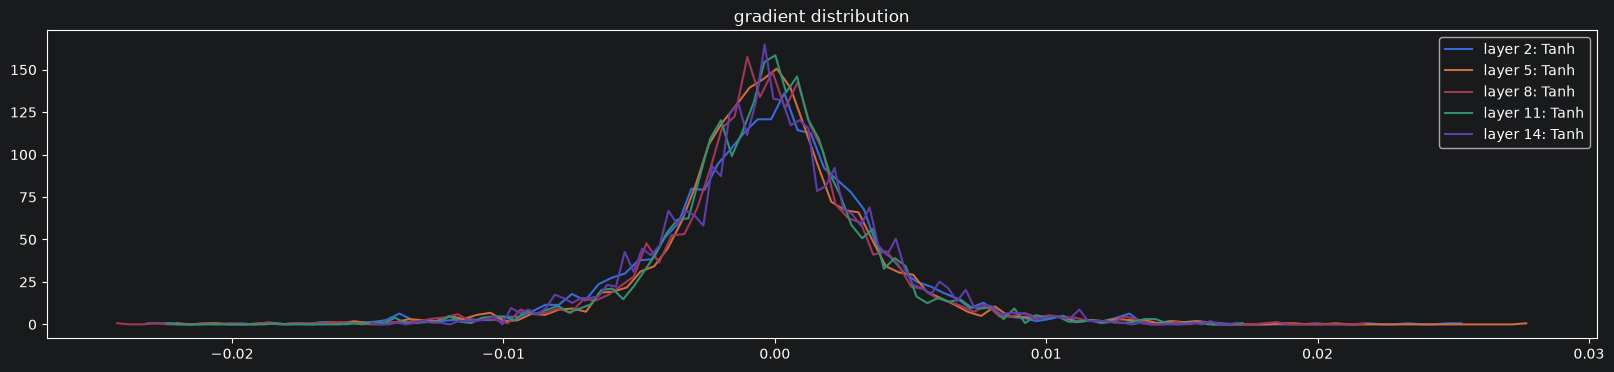

In [11]:
# visualize histograms
plt.figure(figsize = (20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean().item(), t.std().item()))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i}: {layer.__class__.__name__}')
plt.legend(legends)
plt.title('gradient distribution')

weight   (27, 10)| mean +0.000000| std 1.317706e-02| grad:data ratio 1.204974e-02
weight  (30, 100)| mean -0.000169| std 8.986551e-03| grad:data ratio 2.210522e-02
weight (100, 100)| mean -0.000111| std 6.119237e-03| grad:data ratio 2.489671e-02
weight (100, 100)| mean -0.000026| std 6.297362e-03| grad:data ratio 2.590835e-02
weight (100, 100)| mean +0.000043| std 5.953887e-03| grad:data ratio 2.500518e-02
weight (100, 100)| mean +0.000015| std 4.987126e-03| grad:data ratio 2.183672e-02
weight  (100, 27)| mean -0.000070| std 9.080040e-03| grad:data ratio 2.762670e-02


Text(0.5, 1.0, 'weights gradient distribution')

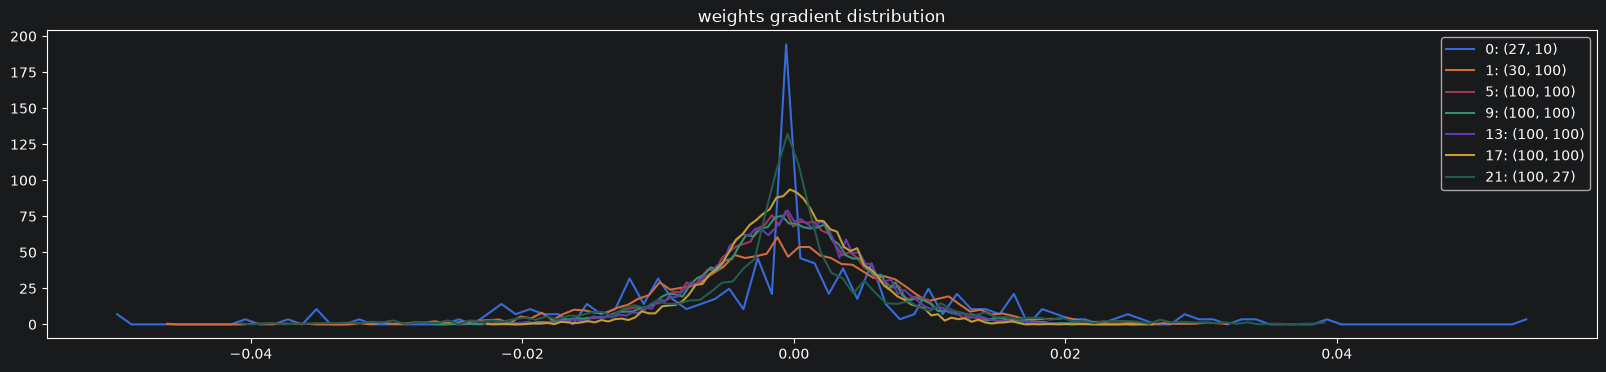

In [12]:
# visualize histograms
plt.figure(figsize = (20, 4))
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print('weight %10s| mean %+f| std %e| grad:data ratio %e' % (tuple(p.shape), t.mean().item(), t.std().item(), t.std().item() / p.std().item()))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i}: {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution')

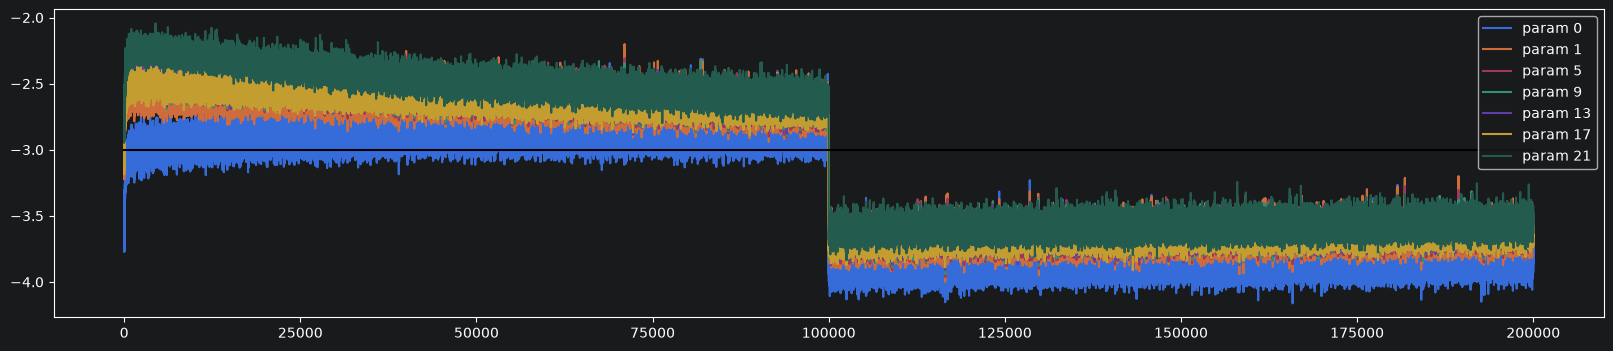

In [13]:
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

In [14]:
# sample from the model
for layer in layers:
    if isinstance(layer, BatchNorm1d):
        layer.training = False

g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      x = emb.view(emb.shape[0], -1) # concatenate the vectors
      for layer in layers:
        x = layer(x)
      logits = x
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break

    print(''.join(itos[i] for i in out)) # decode and print the generated word

carlaizabelle.
khyrily.
reity.
skanden.
jazhith.
deliah.
jareei.
ner.
kia.
chaiir.
kaleigh.
ham.
joce.
quintis.
lilea.
jadiquinterri.
jaryxia.
kael.
dus.
brex.
